<a href="https://colab.research.google.com/github/BasuAI/BasuAI/blob/main/SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import shap
shap.initjs()

In [ ]:
#read the file
df = pd.read_csv('/content/test data.csv')

In [ ]:
df
print(len(df))
df.head()

50


,Id,Subbasin,Rbm,Dd,Fs,Cr,Sf,Cc,Ff,Dt,...,Dtr,Ifn,Lof,Ccm,Rt,Rr,Rn,Hi,Ms,Pc
0,1,L,2.250000,0.837578,1.222221,0.591077,0.975136,1.300727,1.025498,1.023705,...,1.474562,1.023705,0.418789,1.193919,0.041027,42,0.035178,0.411424,2.396901,1.000766
1,2,L,2.500000,0.983974,1.129657,0.608721,2.066813,1.281737,0.483837,1.111554,...,1.424956,1.111554,0.491987,1.016287,0.047681,53,0.052151,0.474819,2.367229,0.999347
2,3,L,4.047619,0.905842,0.754961,0.377701,2.884296,1.627175,0.346705,0.683876,...,0.724318,0.683876,0.452921,1.103945,0.140376,96,0.086961,0.399940,2.207593,0.999995
3,4,L,3.000000,0.997787,0.580604,0.419664,2.789152,1.543680,0.358532,0.579319,...,2.165300,0.579319,0.498893,1.002218,0.108748,63,0.062861,0.433064,2.219951,1.000169
4,5,L,3.250000,0.985779,0.810937,0.376665,2.280709,1.629410,0.438460,0.799405,...,1.851583,0.799405,0.492890,1.014426,0.110082,88,0.086749,0.261193,2.210950,1.000486


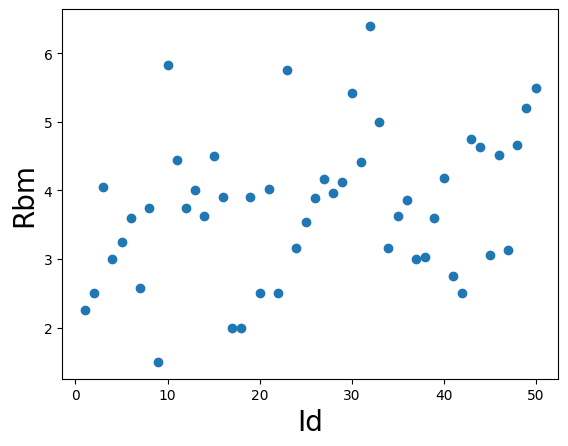

In [ ]:
#plot 1
plt.scatter(df['Id'], df['Rbm'])
plt.ylabel('Rbm', size=20)
plt.xlabel('Id', size=20)
plt.show()

<Axes: >

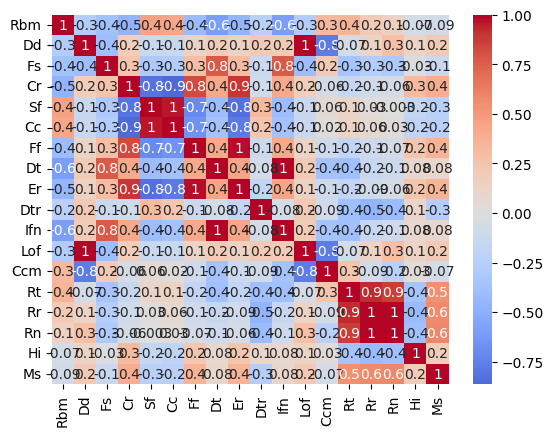

In [ ]:
count = df.iloc[:,2:20].columns
corr_matrix = pd.DataFrame(df[count],columns=count).corr()
sns.heatmap (corr_matrix,cmap='coolwarm',
            center=0,
            annot=True,
            fmt='.1g')

In [ ]:
y=df['Id']
x=df.iloc[:,2:20]

In [ ]:
#Create dummy variables

x = pd.DataFrame({'Subbasin': pd.Series(['L', 'R', 'T', 'L'])})  # Create a DataFrame with 'Subbasin' column
x['Subbasin.L'] = [1 if s == 'L' else 0 for s in x['Subbasin']]
x['Subbasin.R'] = [1 if s == 'R' else 0 for s in x['Subbasin']]
x['Subbasin.T'] = [1 if s == 'T' else 0 for s in x['Subbasin']]

x = x.drop('Subbasin', axis=1)
x.head()





,Subbasin.L,Subbasin.R,Subbasin.T
0,1,0,0
1,0,1,0
2,0,0,1
3,1,0,0


In [ ]:
model = xgb.XGBRegressor (objective="reg:squarederror")
model.fit(X,Y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

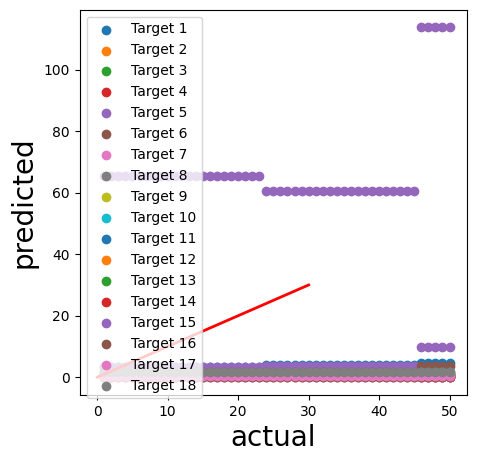

In [ ]:
y_pred = model.predict(X)
plt.figure(figsize=(5, 5))

# Iterate through the columns (targets) of y_pred
for i in range(y_pred.shape[1]):
    plt.scatter(y, y_pred[:, i], label=f'Target {i+1}')  # Plot each target separately

plt.plot([0, 30], [0, 30], color='r', linestyle='-', linewidth=2)
plt.ylabel('predicted', size=20)
plt.xlabel('actual', size=20)
plt.legend()  # Add a legend to distinguish targets
plt.show()

In [ ]:

explainer = shap.Explainer(model, feature_names=X.columns)
shap_values = explainer(X)


IndexError: index 14 is out of bounds for axis 1 with size 3

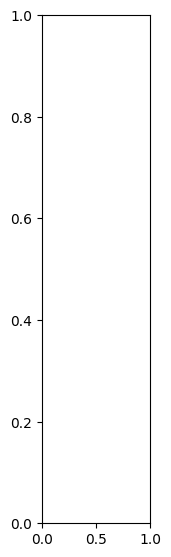

In [ ]:
shap.summary_plot(shap_values, X, plot_type="bar")